In [1]:
import os
from pathlib import Path
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from torchvision.models import EfficientNet_B0_Weights



In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
DATASET_DIR = "peakmodel_dataset"          # root folder with good/ and bad/ subfolders
IMG_SIZE    = 224                # all images resized to this
BATCH_SIZE  = 32
EPOCHS      = 15
LR          = 1e-4
VAL_SPLIT   = 0.2
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_PATH   = "peak_model.pt"
# ─────────────────────────────────────────────────────────────────────────────


In [ ]:

def get_transforms():
    """
    Augment heavily — the dataset is varied and bad images differ only in
    geometric distortions, so spatial augmentation helps generalisation.
    """
    train_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),     # handle random input sizes
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],  # ImageNet stats
                             [0.229, 0.224, 0.225]),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    return train_tf, val_tf


def build_model(num_classes=2):
    """EfficientNet-B0 pretrained on ImageNet, head replaced for binary task."""
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model

def predict(image_path: str=None, img_raw: Image = None, model_path: str = "peak_model.pt") -> dict:
    """
    Predict whether a single image is good (1) or bad (0).
    Works on images of any size.
    """
    from PIL import Image

    _, val_tf = get_transforms()
    model = build_model().to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    if image_path:
        img    = Image.open(image_path).convert("RGB")
    elif img_raw:
        img = img_raw
    else:
        raise ValueError("No image given!")
    tensor = val_tf(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()

    label = int(probs.argmax().item())
    return {
        "label":       label,
        "prediction":  "good" if label == 1 else "bad",
        "confidence":  round(probs[label].item(), 4),
        "prob_good":   round(probs[1].item(), 4),
        "prob_bad":    round(probs[0].item(), 4),
    }

In [20]:
from PIL import Image
imgs = {}
for s in os.listdir("imgs/test-imgs/shapes"):
    imgs[s] = Image.open("imgs/test-imgs/shapes/"+s).convert("RGB")

print(imgs)

{'noodle.png': <PIL.Image.Image image mode=RGB size=3024x1475 at 0x1352DB070>, 'doritp.png': <PIL.Image.Image image mode=RGB size=3024x1475 at 0x1352DB120>, 'notpeak.png': <PIL.Image.Image image mode=RGB size=3024x1646 at 0x1352FAD50>, 'wall.png': <PIL.Image.Image image mode=RGB size=3024x1475 at 0x141F5B570>, 'grill.png': <PIL.Image.Image image mode=RGB size=3024x1475 at 0x141F5B890>, 'sick.png': <PIL.Image.Image image mode=RGB size=3024x1475 at 0x141F5BD90>}


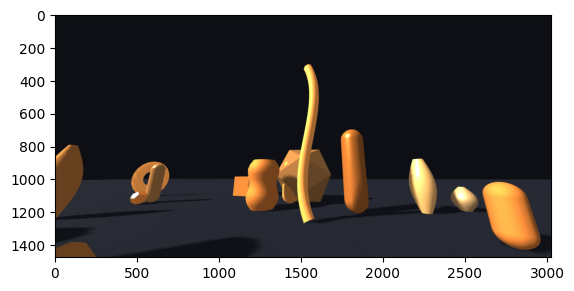

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(imgs['noodle.png'])

In [22]:
for s, im in imgs.items():
    print(f"{s}: {predict(None, im)}")

noodle.png: {'label': 0, 'prediction': 'bad', 'confidence': 0.9734, 'prob_good': 0.0266, 'prob_bad': 0.9734}
doritp.png: {'label': 0, 'prediction': 'bad', 'confidence': 0.9917, 'prob_good': 0.0083, 'prob_bad': 0.9917}
notpeak.png: {'label': 0, 'prediction': 'bad', 'confidence': 0.9964, 'prob_good': 0.0036, 'prob_bad': 0.9964}
wall.png: {'label': 0, 'prediction': 'bad', 'confidence': 0.9845, 'prob_good': 0.0155, 'prob_bad': 0.9845}
grill.png: {'label': 0, 'prediction': 'bad', 'confidence': 0.9402, 'prob_good': 0.0598, 'prob_bad': 0.9402}
sick.png: {'label': 0, 'prediction': 'bad', 'confidence': 0.9837, 'prob_good': 0.0163, 'prob_bad': 0.9837}


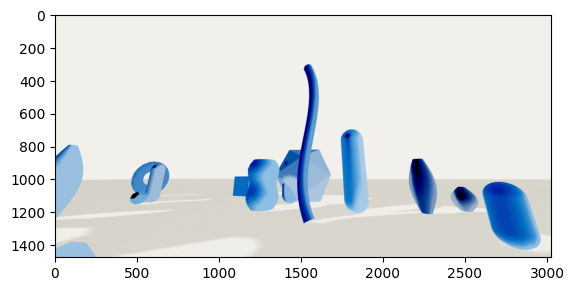

In [23]:
# invert the colors 
from PIL import Image, ImageOps

new_imgs = {}
for s,im in imgs.items():
    new_imgs[s] = ImageOps.invert(im)

# test
plt.imshow(new_imgs['noodle.png'])

In [24]:
for s, im in new_imgs.items():
    print(f"{s}: {predict(None, im)}")

noodle.png: {'label': 0, 'prediction': 'bad', 'confidence': 0.9322, 'prob_good': 0.0678, 'prob_bad': 0.9322}
doritp.png: {'label': 0, 'prediction': 'bad', 'confidence': 0.962, 'prob_good': 0.038, 'prob_bad': 0.962}
notpeak.png: {'label': 0, 'prediction': 'bad', 'confidence': 0.9833, 'prob_good': 0.0167, 'prob_bad': 0.9833}
wall.png: {'label': 0, 'prediction': 'bad', 'confidence': 0.9327, 'prob_good': 0.0673, 'prob_bad': 0.9327}
grill.png: {'label': 0, 'prediction': 'bad', 'confidence': 0.8272, 'prob_good': 0.1728, 'prob_bad': 0.8272}
sick.png: {'label': 0, 'prediction': 'bad', 'confidence': 0.973, 'prob_good': 0.027, 'prob_bad': 0.973}


In [ ]:
predict("imgs/test-imgs/shapes/test_shapeworld.png") # og
block = Image.open("imgs/test-imgs/shapes/test_shapeworld.png").convert("RGB")
anti_block = ImageOps.invert(block)
predict(None, img_raw=anti_block)

TypeError: predict() missing 1 required positional argument: 'image_path'